In [1]:
%%capture
%pip install -q --upgrade pip
%pip install -q "dynamiqs>=0.3.0" cmaes scipy

# Align jax / jaxlib / CUDA plugin (avoids xla::GetCApiClient native crashes)
%pip uninstall -y -q jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt jax-cuda13-plugin jax-cuda13-pjrt
%pip install -q -U "jax[cuda12]"

In [2]:
import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt
import jax

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

import jax
print("JAX", jax.__version__, "| devices:", jax.devices())

# dq.set_progress_meter(False)

JAX 0.9.2 | devices: [CudaDevice(id=0)]


In [3]:
# ── Hilbert space truncation ──────────────────────────────────────────────────
# NA: number of Fock states kept for the storage mode.
#     Must be large enough to contain |alpha|^2 mean photons.
#     With alpha ~ 2, <n> ~ 4, so NA=15 gives plenty of headroom.
# NB: buffer mode truncation. Buffer stays near vacuum (fast decay),
#     so NB=5 is sufficient.
NA = 15
NB = 5

# ── Hardware loss rates [MHz] ─────────────────────────────────────────────────
# KAPPA_B: buffer decay rate. Intentionally large (10 MHz) so the buffer
#          can be adiabatically eliminated, leaving effective 2-photon
#          dissipation on the storage. The condition kappa_b >> |g2| must hold.
# KAPPA_A: single-photon loss of the storage resonator (1 MHz).
#          This is the dominant error channel — it drives both phase flips
#          (fast, ~1/kappa_a) and, indirectly, bit flips (slow, exponential in alpha^2).
KAPPA_B = 10.0
KAPPA_A = 1.0

T_X_EVAL = 1.0
T_Z_EVAL = 50.0

# ── Loss weights ─────────────────────────────────────────────────────────────
# These control the trade-off between the three objectives.
# Increase LAMBDA_X / LAMBDA_Z to prioritize raw lifetime.
# Increase LAMBDA_BIAS to strictly enforce the target bias ratio.
LAMBDA_X    = 1.0    # weight on the T_X proxy reward
LAMBDA_Z    = 0.5    # weight on the T_Z proxy reward (lower: T_Z is harder to improve)
LAMBDA_BIAS = 0.1    # penalty weight for deviating from ETA_TARGET

# Target bias: eta = T_Z / T_X.
# Cat qubits are biased — we want T_Z >> T_X to exploit the noise asymmetry
ETA_TARGET  = 3000.0


ALPHA_TARGET = 2.0   # desired cat size (mean photon number = alpha^2 = 4)
LAMBDA_ALPHA = 0.5   # penalty weight — raise to enforce more strictly


In [4]:
#tz = decay of z operator => bit flip
#tx = decay of x operator => phase flip

@jit
def cat_loss_func(x):
  a, b = dq.destroy(NA, NB)

  #x[0] = g2.real, x[1] = g2.imag, x[2] = ed.real, x[3] = ed.imag
  g2 = x[0] + 1j * x[1]
  ed = x[2] + 1j * x[3]

  kappa_2   = 4.0 * jnp.abs(g2)**2 / KAPPA_B
  eps_2     = 2.0 * g2 * ed / KAPPA_B
  alpha = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))


  #known hamiltonian for two-qubit dissipation
  H = g2.conj() * (a @ a @ b.dag()) + g2 * (a.dag() @ a.dag() @ b) - ed * b.dag() - ed.conj() * b

  jump_ops = [jnp.sqrt(KAPPA_B) * b,
                jnp.sqrt(KAPPA_A) * a] #losses for photon dissipation channels

  cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))  # |+z_L> = |+alpha> x |0>_b
  cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))  # |-z_L> = |-alpha> x |0>_b

  psi_x = (cat_pos + cat_neg) / jnp.sqrt(2)

  parity = (1j * jnp.pi * (a.dag() @ a)).expm()

  res_x = dq.mesolve(
        H, jump_ops, psi_x,
        jnp.array([0.0, T_X_EVAL]),  # only need the final time point
        exp_ops=[parity],
        options=dq.Options(progress_meter=False)
    )

  p0 = res_x.expects[0, 0].real
  p1 = res_x.expects[0, 1].real

  dp_dt = (p1 - p0) / T_X_EVAL
  tx_proxy = -1.0 / (dp_dt + 1e-8)   # T_X estimate in units of T_X_EVAL
  sx_val = 1.0 / tx_proxy             # = 1/T_X; small means long T_X (good)

   # Logical Z observable: Z_L = |+z_L><+z_L| - |-z_L><-z_L|
    #   - +1 when the state is in |+alpha> (logical |0>)
    #   - -1 when the state is in |-alpha> (logical |1>)
    #   - Requires alpha_est to construct — less robust than parity
  sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
  z_logical  = dq.tensor(sz_storage, dq.eye(NB))  # extend to full storage x buffer space

  # ── T_Z proxy: bit-flip lifetime ─────────────────────────────────────────
    # Initial state: |+z_L> = |+alpha> (<Z_L>=+1 at t=0)
    # Bit flips (|+alpha> -> |-alpha>) are exponentially suppressed in alpha^2,
    # so we probe at a much longer time T_Z_EVAL.
    # A higher <Z_L> at T_Z_EVAL means fewer bit flips, i.e., longer T_Z.
  res_z = dq.mesolve(
        H, jump_ops, cat_pos,
        jnp.array([0.0, T_Z_EVAL]),  # only need the final time point
        exp_ops=[z_logical],
        options=dq.Options(progress_meter=False)
    )
    # res_z.expects shape: [n_obs, n_times] -> take observable 0, final time
  sz_val = res_z.expects[0, -1].real
  # ── Bias proxy and penalty ────────────────────────────────────────────────
    # eta = T_Z / T_X.
    # T_X estimate: tx_proxy = 1/sx_val  (from parity decay slope)
    # T_Z estimate: invert the exponential decay sz_val = exp(-T_Z_EVAL / T_Z)
    #               -> T_Z = -T_Z_EVAL / log(sz_val)
    # eta_proxy = T_Z_est / T_X_est = t_z_est * sx_val
  t_z_est   = -T_Z_EVAL / jnp.log(jnp.clip(sz_val, 1e-8, 1.0 - 1e-8))
  eta_proxy = t_z_est * sx_val          # dimensionless; grows with bias
    # Squared deviation from target: zero when eta_proxy == ETA_TARGET
  bias_penalty = (eta_proxy / ETA_TARGET - 1.0) ** 2

  alpha_penalty = (alpha - ALPHA_TARGET)**2

    # ── Combined loss ─────────────────────────────────────────────────────────
    # Negative rewards become positive losses (CMA-ES minimizes):
    #   -LAMBDA_X * sx_val   : reward for small sx (= long T_X, good protection)
    #   -LAMBDA_Z * sz_val   : reward for large sz (= long T_Z, ideal=1)
    #   +LAMBDA_BIAS * ...   : penalty for eta_proxy far from ETA_TARGET
    #   +LAMBDA_ALPHA * ...  : penalty for deviating from target alpha
  loss = (-LAMBDA_X * sx_val
            - LAMBDA_Z * sz_val
            + LAMBDA_BIAS * bias_penalty
            + LAMBDA_ALPHA * alpha_penalty)
  return loss

batched_cat_loss_func = jit(vmap(cat_loss_func))

In [5]:
@jit
def cat_diagnostics(x):
    """Return (sx_val, sz_val, alpha) for a single parameter vector x."""
    a, b = dq.destroy(NA, NB)

    g2 = x[0] + 1j * x[1]
    ed = x[2] + 1j * x[3]

    kappa_2 = 4.0 * jnp.abs(g2)**2 / KAPPA_B
    eps_2   = 2.0 * g2 * ed / KAPPA_B
    alpha   = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    H = g2.conj() * (a @ a @ b.dag()) + g2 * (a.dag() @ a.dag() @ b) - ed * b.dag() - ed.conj() * b
    jump_ops = [jnp.sqrt(KAPPA_B) * b, jnp.sqrt(KAPPA_A) * a]

    cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))
    cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))
    psi_x   = (cat_pos + cat_neg) / jnp.sqrt(2)

    parity = (1j * jnp.pi * (a.dag() @ a)).expm()

    res_x = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_X_EVAL]),
                       exp_ops=[parity], options=dq.Options(progress_meter=False))
    p0 = res_x.expects[0, 0].real
    p1 = res_x.expects[0, 1].real
    dp_dt   = (p1 - p0) / T_X_EVAL
    tx_proxy = -1.0 / (dp_dt + 1e-8)
    sx_val  = 1.0 / tx_proxy

    sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))

    res_z = dq.mesolve(H, jump_ops, cat_pos, jnp.array([0.0, T_Z_EVAL]),
                       exp_ops=[z_logical], options=dq.Options(progress_meter=False))
    sz_val = res_z.expects[0, -1].real

    return sx_val, sz_val, alpha

In [6]:
BATCH_SIZE = 8   # CMA-ES population size (number of candidates per epoch)
N_EPOCHS   = 60   # total number of optimization epochs

# ── CMA-ES setup ─────────────────────────────────────────────────────────────
mean0  = jnp.array([1.0, 0.0, 4.0, 0.0])
sigma0 = 0.3

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [0.1,  5.0],   # Re(g2)
        [-2.0, 2.0],   # Im(g2)
        [0.5, 10.0],   # Re(eps_d)
        [-2.0, 2.0],   # Im(eps_d)
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ── Logging ───────────────────────────────────────────────────────────────────
mean_history     = []
loss_history     = []
loss_std_history = []
sx_history       = []   # phase-flip proxy at optimizer mean
sz_history       = []   # bit-flip proxy at optimizer mean
alpha_history    = []   # effective cat size at optimizer mean

# ── Training loop ────────────────────────────────────────────────────────────
for epoch in range(N_EPOCHS):

    xs = jnp.array([optimizer.ask() for _ in range(optimizer.population_size)])
    losses = batched_cat_loss_func(xs)

    solutions = [(xs[i], float(losses[i])) for i in range(len(xs))]
    solutions.sort(key=lambda sv: sv[1])
    optimizer.tell(solutions)

    # Diagnostics on the current mean (best estimate)
    sx_v, sz_v, alpha_v = cat_diagnostics(jnp.array(optimizer.mean))

    mean_history.append(optimizer.mean.copy())
    loss_history.append(float(losses.mean()))
    loss_std_history.append(float(losses.std()))
    sx_history.append(float(sx_v))
    sz_history.append(float(sz_v))
    alpha_history.append(float(alpha_v))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss {loss_history[-1]:.4f} | "
              f"sx {sx_v:.4f}  sz {sz_v:.4f}  alpha {alpha_v:.3f} | "
              f"params {optimizer.mean}")

# Convert to JAX arrays for plotting
mean_history     = jnp.array(mean_history)
loss_history     = jnp.array(loss_history)
loss_std_history = jnp.array(loss_std_history)
sx_history       = jnp.array(sx_history)
sz_history       = jnp.array(sz_history)
alpha_history    = jnp.array(alpha_history)

/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Epoch   0 | loss -0.8216 | sx 0.9269  sz 0.4243  alpha 1.605 | params [1.162505   0.08567849 4.111209   0.33135822]
Epoch  10 | loss -1.1817 | sx 0.9837  sz 0.7282  alpha 2.003 | params [ 0.8692793  -0.14287636  4.8954973   0.76161295]
Epoch  20 | loss -1.3028 | sx 0.9912  sz 0.8597  alpha 1.986 | params [ 1.3972787  -0.37768775  6.3924265   1.5296067 ]
Epoch  30 | loss -1.3479 | sx 0.9926  sz 0.8763  alpha 1.960 | params [ 1.6530936 -0.3861631  7.069978   1.6498337]
Epoch  40 | loss -1.3208 | sx 0.9952  sz 0.8921  alpha 1.955 | params [ 2.169383   -0.38100633  8.875435    1.4171374 ]
Epoch  50 | loss -1.3685 | sx 0.9954  sz 0.8948  alpha 1.947 | params [ 2.3595967 -0.4383584  9.461509   1.7284908]


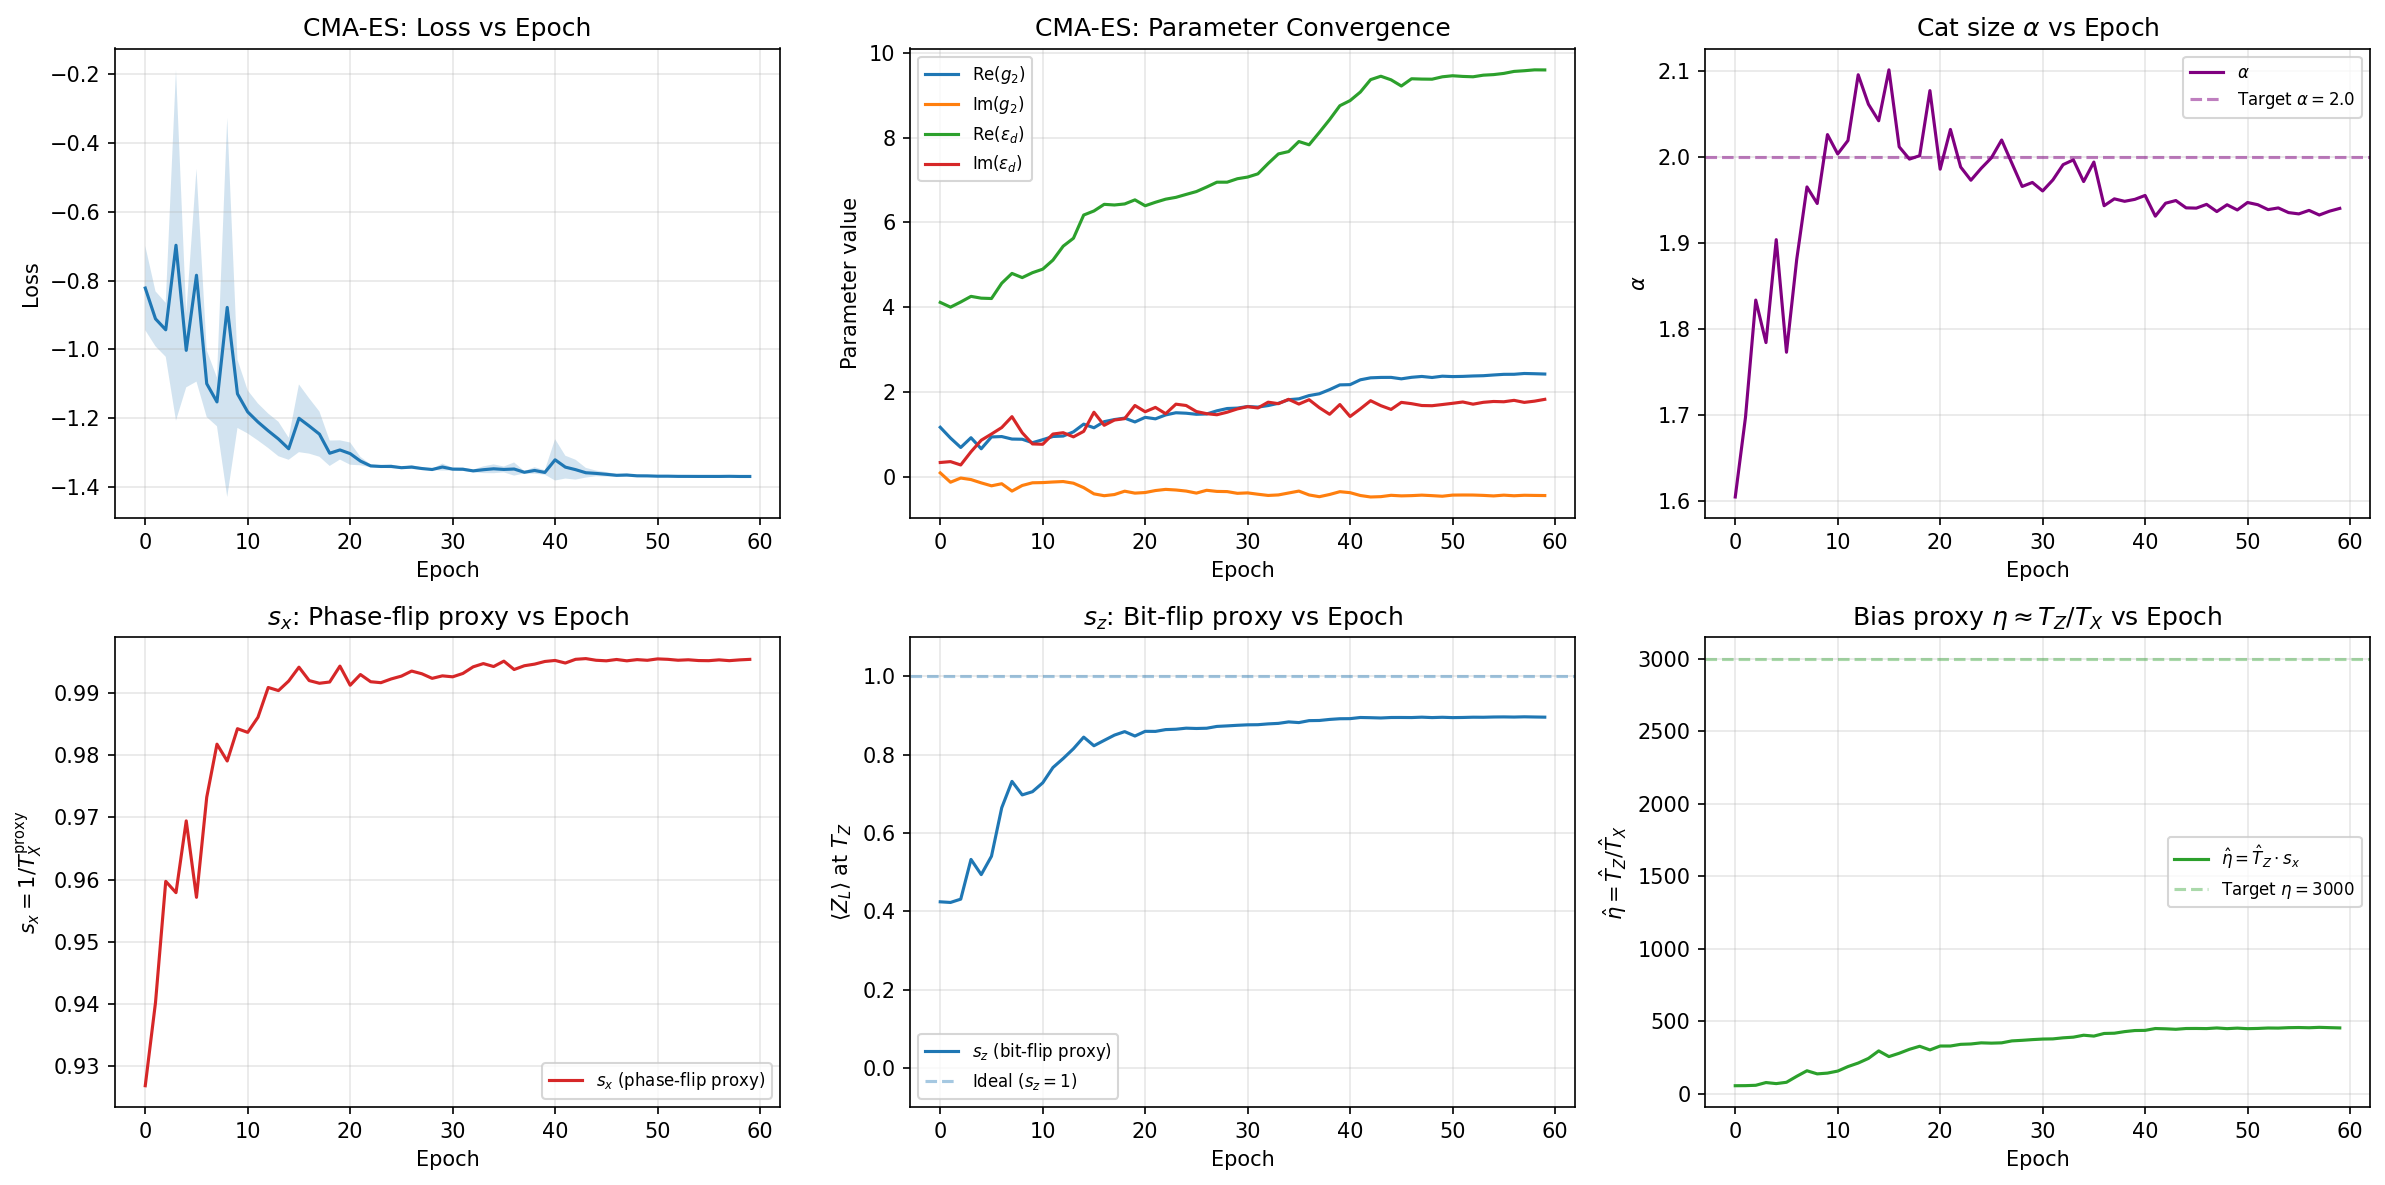


Final optimizer mean: [ 2.4195104 -0.448981   9.598917   1.822321 ]
  sx = 0.995372  (= 1/T_X proxy)
  sz = 0.895898  (higher = longer T_Z, ideal=1)
  alpha = 1.9401  (target=2.0)
  eta proxy = 452.7  (target=3000)


In [7]:
epochs = jnp.arange(N_EPOCHS)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=150)

# ── Row 0, Col 0: Loss vs epoch ───────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs, loss_history, label="Mean loss")
ax.fill_between(epochs,
                loss_history - loss_std_history,
                loss_history + loss_std_history,
                alpha=0.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CMA-ES: Loss vs Epoch")
ax.grid(True, alpha=0.3)

# ── Row 0, Col 1: Parameter convergence ──────────────────────────────────────
ax = axes[0, 1]
labels = [r"$\mathrm{Re}(g_2)$", r"$\mathrm{Im}(g_2)$",
          r"$\mathrm{Re}(\epsilon_d)$", r"$\mathrm{Im}(\epsilon_d)$"]
for k, lbl in enumerate(labels):
    ax.plot(epochs, mean_history[:, k], label=lbl)
ax.set_xlabel("Epoch")
ax.set_ylabel("Parameter value")
ax.set_title("CMA-ES: Parameter Convergence")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Row 0, Col 2: Alpha (cat size) vs epoch ───────────────────────────────────
ax = axes[0, 2]
ax.plot(epochs, alpha_history, color="purple", label=r"$\alpha$")
ax.axhline(ALPHA_TARGET, color="purple", linestyle="--", alpha=0.5, label=rf"Target $\alpha={ALPHA_TARGET}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\alpha$")
ax.set_title(r"Cat size $\alpha$ vs Epoch")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Row 1, Col 0: sx (phase-flip proxy) vs epoch ─────────────────────────────
# sx = 1/T_X proxy: small sx means long phase-flip time (good).
# Should decrease (or stay small) as optimization progresses.
ax = axes[1, 0]
ax.plot(epochs, sx_history, color="tab:red", label=r"$s_x$ (phase-flip proxy)")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$s_x = 1/T_X^{\rm proxy}$")
ax.set_title(r"$s_x$: Phase-flip proxy vs Epoch")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Row 1, Col 1: sz (bit-flip proxy) vs epoch ───────────────────────────────
# sz = <Z_L> at T_Z_EVAL: close to +1 means long bit-flip time (good).
# Should increase toward 1 as optimization progresses.
ax = axes[1, 1]
ax.plot(epochs, sz_history, color="tab:blue", label=r"$s_z$ (bit-flip proxy)")
ax.axhline(1.0, color="tab:blue", linestyle="--", alpha=0.4, label="Ideal ($s_z=1$)")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\langle Z_L \rangle$ at $T_Z$")
ax.set_title(r"$s_z$: Bit-flip proxy vs Epoch")
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Row 1, Col 2: Bias proxy (T_Z_est / T_X_est) vs epoch ───────────────────
# T_Z estimated by inverting exponential decay: sz = exp(-T_Z_EVAL/T_Z) -> T_Z = -T_Z_EVAL/log(sz)
# T_X = 1/sx_val = tx_proxy; eta = T_Z/T_X = t_z_est * sx_val
t_z_est_history = -T_Z_EVAL / jnp.log(jnp.clip(sz_history, 1e-8, 1.0 - 1e-8))
eta_history = t_z_est_history * sx_history
ax = axes[1, 2]
ax.plot(epochs, eta_history, color="tab:green", label=r"$\hat{\eta} = \hat{T}_Z \cdot s_x$")
ax.axhline(ETA_TARGET, color="tab:green", linestyle="--", alpha=0.4,
           label=rf"Target $\eta={ETA_TARGET:.0f}$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\hat{\eta} = \hat{T}_Z / \hat{T}_X$")
ax.set_title(r"Bias proxy $\eta \approx T_Z/T_X$ vs Epoch")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final values
print(f"\nFinal optimizer mean: {optimizer.mean}")
print(f"  sx = {sx_history[-1]:.6f}  (= 1/T_X proxy)")
print(f"  sz = {sz_history[-1]:.6f}  (higher = longer T_Z, ideal=1)")
print(f"  alpha = {alpha_history[-1]:.4f}  (target={ALPHA_TARGET})")
print(f"  eta proxy = {float(eta_history[-1]):.1f}  (target={ETA_TARGET:.0f})")

## Section 3 — Drift and Noise Modeling

We inject four classes of environmental drift and test whether CMA-ES can adapt:

| Drift type | Hamiltonian / readout change | Compensation knob? |
|---|---|---|
| **g₂ amplitude shift** | `g2_hw = g2_opt · (1+δA) · e^{iφ}` | No (implicit via Re/Im g₂) |
| **Storage detuning** | `H += Δₐ a†a` | Yes: `x[4] = Δd` directly cancels it |
| **Kerr nonlinearity** | `H += K/2 · (n² − n)` | No (optimizer adjusts g₂/εd implicitly) |
| **Measurement SNR** | Gaussian noise on loss evaluations | N/A |

A **step-function drift** (sudden onset at `STEP_EPOCH = N_EPOCHS // 2`) is the primary benchmark — the abrupt discontinuity gives the clearest signal for measuring recovery speed.

In [8]:
# ── Drifted loss functions ─────────────────────────────────────────────────────
#
# drift_params: jnp.array([amp_frac, phase_rad, delta_a, kerr_K])
#   amp_frac  - fractional amplitude change on g2 (0 = no drift)
#   phase_rad - extra phase added to g2 in radians (0 = no drift)
#   delta_a   - storage resonator detuning [MHz]
#   kerr_K    - self-Kerr coefficient K [MHz]; adds K/2 * (n^2 - n) to H
#
# Two variants:
#   cat_loss_func_drifted  -- 4-param x, covers amp/phase/detuning/Kerr drift
#   cat_loss_func_comp     -- 5-param x, x[4] = Delta_d cancels delta_a detuning

@jit
def cat_loss_func_drifted(x, drift_params):
    a, b = dq.destroy(NA, NB)

    # Drift acts on the physical hardware coupling, not the optimizer value.
    # Optimizer controls g2_opt; hardware sees g2_hw = g2_opt * drift factor.
    g2_opt  = x[0] + 1j * x[1]
    ed      = x[2] + 1j * x[3]
    g2      = g2_opt * (1.0 + drift_params[0]) * jnp.exp(1j * drift_params[1])
    delta_a = drift_params[2]
    kerr_K  = drift_params[3]

    kappa_2 = 4.0 * jnp.abs(g2)**2 / KAPPA_B
    eps_2   = 2.0 * g2 * ed / KAPPA_B
    alpha   = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    n_a = a.dag() @ a
    H = (g2.conj() * (a @ a @ b.dag())
       + g2 * (a.dag() @ a.dag() @ b)
       - ed * b.dag() - ed.conj() * b
       + delta_a * n_a                          # storage detuning drift
       + (kerr_K / 2.0) * (n_a @ n_a - n_a))   # Kerr: K/2 * a_dag^2 a^2

    jump_ops = [jnp.sqrt(KAPPA_B) * b, jnp.sqrt(KAPPA_A) * a]

    cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))
    cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))
    psi_x   = (cat_pos + cat_neg) / jnp.sqrt(2)
    parity  = (1j * jnp.pi * n_a).expm()

    res_x  = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_X_EVAL]),
                        exp_ops=[parity], options=dq.Options(progress_meter=False))
    dp_dt    = (res_x.expects[0, 1].real - res_x.expects[0, 0].real) / T_X_EVAL
    tx_proxy = -1.0 / (dp_dt + 1e-8)
    sx_val   = 1.0 / tx_proxy

    sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))

    res_z  = dq.mesolve(H, jump_ops, cat_pos, jnp.array([0.0, T_Z_EVAL]),
                        exp_ops=[z_logical], options=dq.Options(progress_meter=False))
    sz_val = res_z.expects[0, -1].real

    t_z_est   = -T_Z_EVAL / jnp.log(jnp.clip(sz_val, 1e-8, 1.0 - 1e-8))
    eta_proxy = t_z_est * sx_val
    bias_penalty = (eta_proxy / ETA_TARGET - 1.0) ** 2
    alpha_penalty = (alpha - ALPHA_TARGET) ** 2

    return (-LAMBDA_X * sx_val - LAMBDA_Z * sz_val
            + LAMBDA_BIAS * bias_penalty + LAMBDA_ALPHA * alpha_penalty)

batched_cat_loss_func_drifted = jit(vmap(cat_loss_func_drifted, in_axes=(0, None)))


@jit
def cat_diagnostics_drifted(x, drift_params):
    """Returns (sx, sz, alpha) under arbitrary drift -- used by the experiment runner."""
    a, b = dq.destroy(NA, NB)

    g2_opt  = x[0] + 1j * x[1]
    ed      = x[2] + 1j * x[3]
    g2      = g2_opt * (1.0 + drift_params[0]) * jnp.exp(1j * drift_params[1])
    delta_a = drift_params[2]
    kerr_K  = drift_params[3]

    kappa_2 = 4.0 * jnp.abs(g2)**2 / KAPPA_B
    eps_2   = 2.0 * g2 * ed / KAPPA_B
    alpha   = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    n_a = a.dag() @ a
    H = (g2.conj() * (a @ a @ b.dag())
       + g2 * (a.dag() @ a.dag() @ b)
       - ed * b.dag() - ed.conj() * b
       + delta_a * n_a
       + (kerr_K / 2.0) * (n_a @ n_a - n_a))

    jump_ops = [jnp.sqrt(KAPPA_B) * b, jnp.sqrt(KAPPA_A) * a]

    cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))
    cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))
    psi_x   = (cat_pos + cat_neg) / jnp.sqrt(2)
    parity  = (1j * jnp.pi * n_a).expm()

    res_x  = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_X_EVAL]),
                        exp_ops=[parity], options=dq.Options(progress_meter=False))
    dp_dt    = (res_x.expects[0, 1].real - res_x.expects[0, 0].real) / T_X_EVAL
    sx_val   = 1.0 / (-1.0 / (dp_dt + 1e-8))

    sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))

    res_z  = dq.mesolve(H, jump_ops, cat_pos, jnp.array([0.0, T_Z_EVAL]),
                        exp_ops=[z_logical], options=dq.Options(progress_meter=False))
    sz_val = res_z.expects[0, -1].real

    return sx_val, sz_val, alpha


# ── Detuning-compensation variant (5-parameter optimizer) ─────────────────────
# x[4] = Delta_d: tunable drive detuning the optimizer learns to cancel delta_a.
# Net detuning seen by the storage = (delta_a - Delta_d).

@jit
def cat_loss_func_comp(x, drift_params):
    a, b = dq.destroy(NA, NB)

    g2      = x[0] + 1j * x[1]
    ed      = x[2] + 1j * x[3]
    delta_d = x[4]               # compensation knob
    delta_a = drift_params[2]    # hardware detuning drift

    kappa_2 = 4.0 * jnp.abs(g2)**2 / KAPPA_B
    eps_2   = 2.0 * g2 * ed / KAPPA_B
    alpha   = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    n_a = a.dag() @ a
    # Net detuning = hardware drift - optimizer's compensation knob
    H = (g2.conj() * (a @ a @ b.dag())
       + g2 * (a.dag() @ a.dag() @ b)
       - ed * b.dag() - ed.conj() * b
       + (delta_a - delta_d) * n_a)

    jump_ops = [jnp.sqrt(KAPPA_B) * b, jnp.sqrt(KAPPA_A) * a]

    cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))
    cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))
    psi_x   = (cat_pos + cat_neg) / jnp.sqrt(2)
    parity  = (1j * jnp.pi * n_a).expm()

    res_x  = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_X_EVAL]),
                        exp_ops=[parity], options=dq.Options(progress_meter=False))
    dp_dt    = (res_x.expects[0, 1].real - res_x.expects[0, 0].real) / T_X_EVAL
    tx_proxy = -1.0 / (dp_dt + 1e-8)
    sx_val   = 1.0 / tx_proxy

    sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))

    res_z  = dq.mesolve(H, jump_ops, cat_pos, jnp.array([0.0, T_Z_EVAL]),
                        exp_ops=[z_logical], options=dq.Options(progress_meter=False))
    sz_val = res_z.expects[0, -1].real

    t_z_est   = -T_Z_EVAL / jnp.log(jnp.clip(sz_val, 1e-8, 1.0 - 1e-8))
    eta_proxy = t_z_est * sx_val
    bias_penalty = (eta_proxy / ETA_TARGET - 1.0) ** 2
    alpha_penalty = (alpha - ALPHA_TARGET) ** 2

    return (-LAMBDA_X * sx_val - LAMBDA_Z * sz_val
            + LAMBDA_BIAS * bias_penalty + LAMBDA_ALPHA * alpha_penalty)

batched_cat_loss_func_comp = jit(vmap(cat_loss_func_comp, in_axes=(0, None)))


@jit
def cat_diagnostics_comp(x, drift_params):
    """Diagnostics for the 5-param detuning-compensation variant."""
    a, b = dq.destroy(NA, NB)

    g2      = x[0] + 1j * x[1]
    ed      = x[2] + 1j * x[3]
    delta_d = x[4]
    delta_a = drift_params[2]

    kappa_2 = 4.0 * jnp.abs(g2)**2 / KAPPA_B
    eps_2   = 2.0 * g2 * ed / KAPPA_B
    alpha   = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    n_a = a.dag() @ a
    H = (g2.conj() * (a @ a @ b.dag())
       + g2 * (a.dag() @ a.dag() @ b)
       - ed * b.dag() - ed.conj() * b
       + (delta_a - delta_d) * n_a)

    jump_ops = [jnp.sqrt(KAPPA_B) * b, jnp.sqrt(KAPPA_A) * a]

    cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))
    cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))
    psi_x   = (cat_pos + cat_neg) / jnp.sqrt(2)
    parity  = (1j * jnp.pi * n_a).expm()

    res_x  = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_X_EVAL]),
                        exp_ops=[parity], options=dq.Options(progress_meter=False))
    dp_dt    = (res_x.expects[0, 1].real - res_x.expects[0, 0].real) / T_X_EVAL
    sx_val   = 1.0 / (-1.0 / (dp_dt + 1e-8))

    sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))

    res_z  = dq.mesolve(H, jump_ops, cat_pos, jnp.array([0.0, T_Z_EVAL]),
                        exp_ops=[z_logical], options=dq.Options(progress_meter=False))
    sz_val = res_z.expects[0, -1].real

    return sx_val, sz_val, alpha

print("Drifted loss functions defined.")

Drifted loss functions defined.


In [9]:
import numpy as np

# ── Drift schedule constants ───────────────────────────────────────────────────
STEP_EPOCH = N_EPOCHS // 2   # drift onset epoch for step-function benchmark

# ── Drift schedules ────────────────────────────────────────────────────────────
# Each schedule is a Python callable: epoch (int) -> jnp.array of shape (4,)
# drift_params = [amp_frac, phase_rad, delta_a_MHz, kerr_K_MHz]
# epoch is a plain Python int so Python conditionals work fine here.

def no_drift(epoch):
    return jnp.zeros(4)

# g2 amplitude step: hardware coupling suddenly grows 30% at STEP_EPOCH
def amp_step(epoch, magnitude=0.30):
    return jnp.array([magnitude if epoch >= STEP_EPOCH else 0.0, 0.0, 0.0, 0.0])

# g2 amplitude ramp: linearly grows to 30% over all epochs
def amp_ramp(epoch, magnitude=0.30):
    return jnp.array([magnitude * epoch / N_EPOCHS, 0.0, 0.0, 0.0])

# Storage detuning step: +0.5 MHz sudden offset at STEP_EPOCH
def detuning_step(epoch, magnitude=0.50):
    return jnp.array([0.0, 0.0, magnitude if epoch >= STEP_EPOCH else 0.0, 0.0])

# Storage detuning ramp: linearly grows to 0.5 MHz
def detuning_ramp(epoch, magnitude=0.50):
    return jnp.array([0.0, 0.0, magnitude * epoch / N_EPOCHS, 0.0])

# Kerr step: K = 0.15 MHz suddenly appears at STEP_EPOCH
def kerr_step(epoch, magnitude=0.15):
    return jnp.array([0.0, 0.0, 0.0, magnitude if epoch >= STEP_EPOCH else 0.0])

# Kerr ramp: K linearly grows to 0.15 MHz
def kerr_ramp(epoch, magnitude=0.15):
    return jnp.array([0.0, 0.0, 0.0, magnitude * epoch / N_EPOCHS])

# SNR schedule: measurement SNR degrades linearly (used as snr_fn, not drift_params)
def snr_schedule(epoch, snr_initial=50.0, snr_final=5.0):
    return snr_initial - (snr_initial - snr_final) * epoch / N_EPOCHS


# ── Experiment runner ──────────────────────────────────────────────────────────
def run_drift_experiment(
    name,
    drift_schedule_fn,      # epoch -> drift_params jnp.array(4,)
    batched_loss_fn,        # (xs_batch, drift_params) -> losses
    diag_fn,                # (x_mean, drift_params) -> (sx, sz, alpha)
    mean0,                  # initial optimizer mean (length 4 or 5)
    sigma0=0.3,
    bounds=None,
    snr_fn=None,            # optional: epoch -> float SNR; adds noise to losses
    seed=0,
):
    """
    Runs CMA-ES for N_EPOCHS under the given drift schedule.
    Starts from mean0, which should be the baseline-optimized mean so we are
    testing resilience of a *tuned* system, not re-learning from scratch.

    snr_fn: if provided, Gaussian noise ~ N(0, 1/SNR) is added to each loss
    evaluation before telling the optimizer -- simulating finite measurement SNR.
    The diagnostic (sx, sz) is always evaluated on the true (noiseless) physics.

    Returns a dict of history arrays.
    """
    n_params = len(mean0)
    if bounds is None:
        if n_params == 4:
            bounds = jnp.array([[0.1, 5.0], [-2.0, 2.0],
                                 [0.5, 10.0], [-2.0, 2.0]])
        else:  # 5 params: add Delta_d bound
            bounds = jnp.array([[0.1, 5.0], [-2.0, 2.0],
                                 [0.5, 10.0], [-2.0, 2.0],
                                 [-2.0, 2.0]])

    opt = SepCMA(mean=jnp.array(mean0, dtype=float), sigma=sigma0,
                 bounds=bounds, population_size=BATCH_SIZE, seed=seed)
    rng = np.random.default_rng(seed)

    hist = {k: [] for k in ['loss', 'loss_std', 'sx', 'sz', 'alpha']}

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    for epoch in range(N_EPOCHS):
        drift_params = drift_schedule_fn(epoch)

        xs = jnp.array([opt.ask() for _ in range(opt.population_size)])
        losses = batched_loss_fn(xs, drift_params)

        # Inject readout noise outside JIT (simulates finite SNR on gradient signal)
        if snr_fn is not None:
            snr = snr_fn(epoch)
            noise = jnp.array(rng.standard_normal(len(losses)) / snr)
            losses = losses + noise

        solutions = [(xs[i], float(losses[i])) for i in range(len(xs))]
        solutions.sort(key=lambda sv: sv[1])
        opt.tell(solutions)

        sx_v, sz_v, alpha_v = diag_fn(jnp.array(opt.mean), drift_params)

        hist['loss'].append(float(losses.mean()))
        hist['loss_std'].append(float(losses.std()))
        hist['sx'].append(float(sx_v))
        hist['sz'].append(float(sz_v))
        hist['alpha'].append(float(alpha_v))

        if epoch % 10 == 0 or epoch == STEP_EPOCH:
            tag = " <-- DRIFT STEP" if epoch == STEP_EPOCH else ""
            print(f"  Epoch {epoch:3d} | loss {hist['loss'][-1]:.4f} | "
                  f"sx {sx_v:.4f}  sz {sz_v:.4f}  alpha {alpha_v:.3f}{tag}")

    for k in ['loss', 'loss_std', 'sx', 'sz', 'alpha']:
        hist[k] = jnp.array(hist[k])
    return hist


print(f"Drift schedules and experiment runner defined.  STEP_EPOCH = {STEP_EPOCH}")

Drift schedules and experiment runner defined.  STEP_EPOCH = 30


In [10]:
# ── Run all drift experiments ──────────────────────────────────────────────────
#
# All experiments start from the baseline-optimised mean so we test *resilience*
# of a tuned system rather than re-learning from scratch.
#
# Experiments:
#   1. Baseline (no drift, re-run for fair comparison from same start)
#   2. g2 amplitude step drift
#   3. g2 amplitude ramp drift
#   4. Storage detuning step (no compensation knob)
#   5. Storage detuning step (with Delta_d compensation knob)
#   6. Kerr nonlinearity step drift
#   7. Measurement SNR degradation (50 -> 5 over 60 epochs)

best_mean_4 = jnp.array(optimizer.mean)           # 4-param baseline optimum
best_mean_5 = jnp.concatenate([best_mean_4,
                                jnp.array([0.0])])  # 5-param: Delta_d starts at 0

# 1. Baseline
hist_baseline = run_drift_experiment(
    "1. Baseline (no drift)",
    no_drift,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
)

# 2. g2 amplitude step
hist_amp_step = run_drift_experiment(
    "2. g2 Amplitude Step (+30% at epoch 30)",
    amp_step,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
)

# 3. g2 amplitude ramp
hist_amp_ramp = run_drift_experiment(
    "3. g2 Amplitude Ramp (0 -> +30% over 60 epochs)",
    amp_ramp,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
)

# 4. Storage detuning step, no compensation knob
hist_det_nocomp = run_drift_experiment(
    "4. Storage Detuning Step (+0.5 MHz at epoch 30, no knob)",
    detuning_step,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
)

# 5. Storage detuning step, WITH Delta_d compensation knob
hist_det_comp = run_drift_experiment(
    "5. Storage Detuning Step (+0.5 MHz, Delta_d compensation knob)",
    detuning_step,
    batched_cat_loss_func_comp,
    cat_diagnostics_comp,
    mean0=best_mean_5,
)

# 6. Kerr nonlinearity step
hist_kerr_step = run_drift_experiment(
    "6. Kerr Step (K=0.15 MHz at epoch 30)",
    kerr_step,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
)

# 7. Measurement SNR degradation (no Hamiltonian drift; noise corrupts losses)
hist_snr = run_drift_experiment(
    "7. Measurement SNR Degradation (SNR: 50 -> 5)",
    no_drift,
    batched_cat_loss_func_drifted,
    cat_diagnostics_drifted,
    mean0=best_mean_4,
    snr_fn=snr_schedule,
)

print("\nAll experiments complete.")


  1. Baseline (no drift)


/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


  Epoch   0 | loss -1.2940 | sx 0.9928  sz 0.8954  alpha 1.852
  Epoch  10 | loss -1.3692 | sx 0.9952  sz 0.8971  alpha 1.932
  Epoch  20 | loss -1.3697 | sx 0.9953  sz 0.8977  alpha 1.929
  Epoch  30 | loss -1.3700 | sx 0.9953  sz 0.8977  alpha 1.929 <-- DRIFT STEP
  Epoch  40 | loss -1.3701 | sx 0.9953  sz 0.8978  alpha 1.929
  Epoch  50 | loss -1.3701 | sx 0.9953  sz 0.8978  alpha 1.929

  2. g2 Amplitude Step (+30% at epoch 30)
  Epoch   0 | loss -1.2940 | sx 0.9928  sz 0.8954  alpha 1.852
  Epoch  10 | loss -1.3692 | sx 0.9952  sz 0.8971  alpha 1.932
  Epoch  20 | loss -1.3697 | sx 0.9953  sz 0.8977  alpha 1.929
  Epoch  30 | loss -1.2862 | sx 0.9855  sz 0.8531  alpha 1.703 <-- DRIFT STEP
  Epoch  40 | loss -1.3025 | sx 0.9878  sz 0.8684  alpha 1.739
  Epoch  50 | loss -1.3659 | sx 0.9953  sz 0.8973  alpha 1.931

  3. g2 Amplitude Ramp (0 -> +30% over 60 epochs)
  Epoch   0 | loss -1.2940 | sx 0.9928  sz 0.8954  alpha 1.852
  Epoch  10 | loss -1.3688 | sx 0.9951  sz 0.8975  alpha 

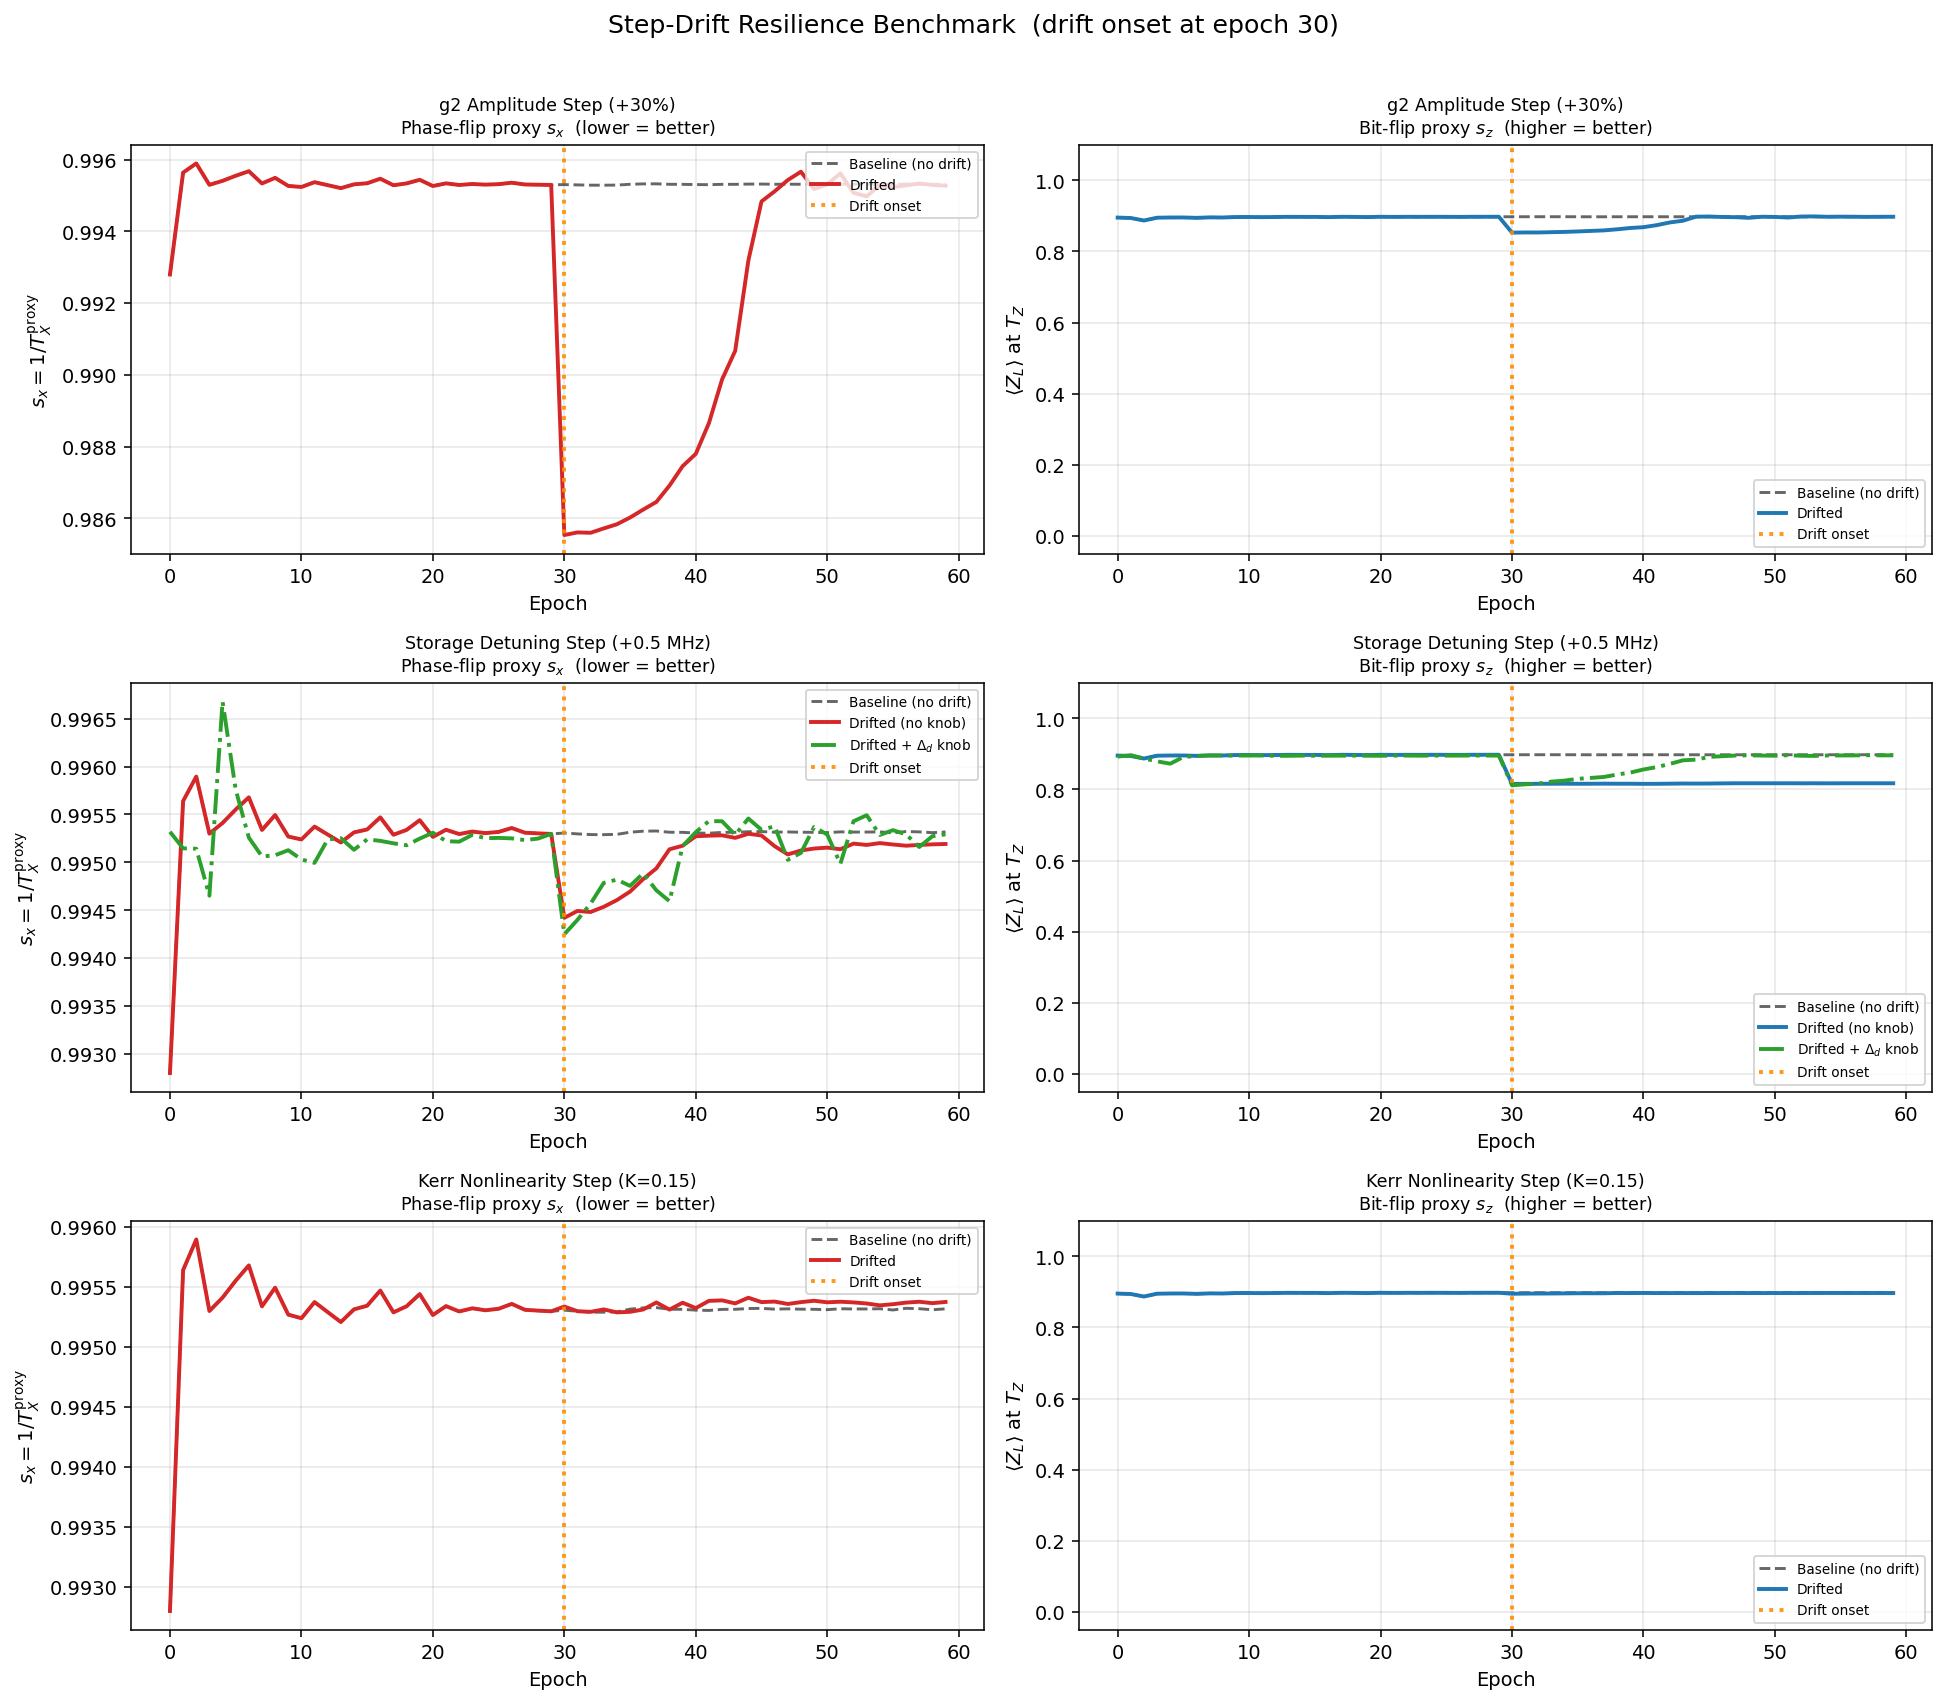

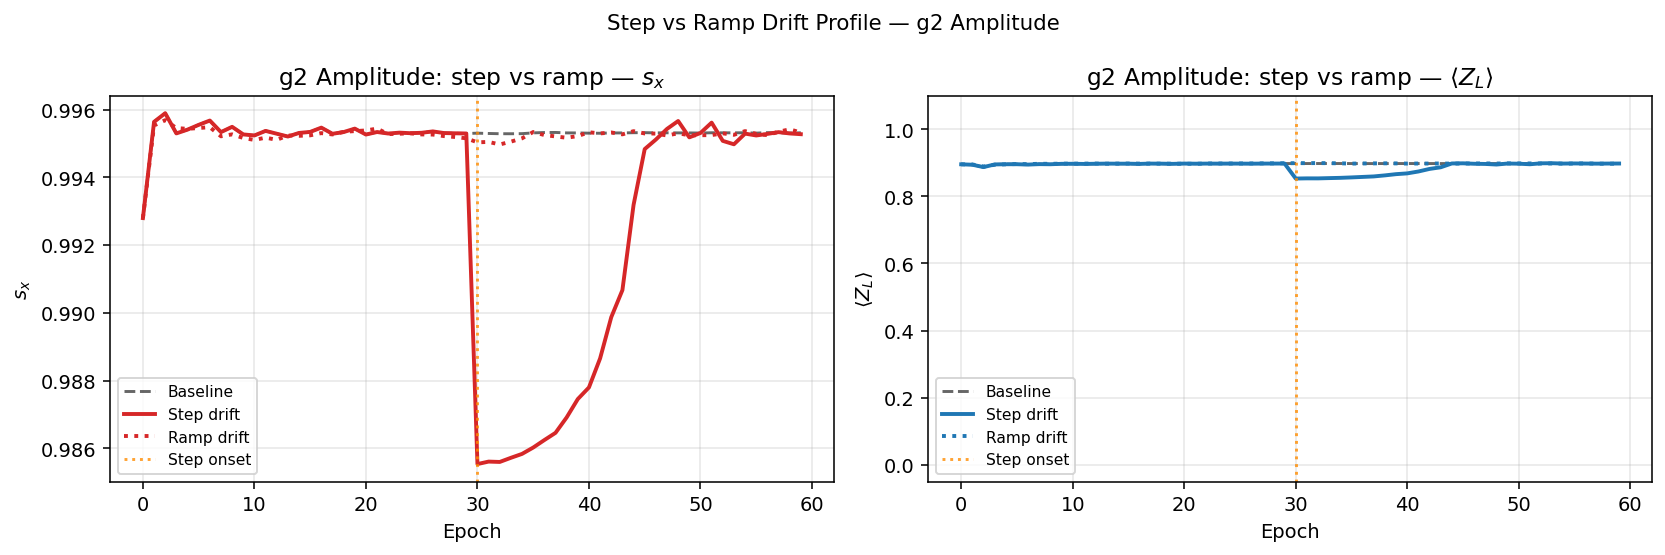

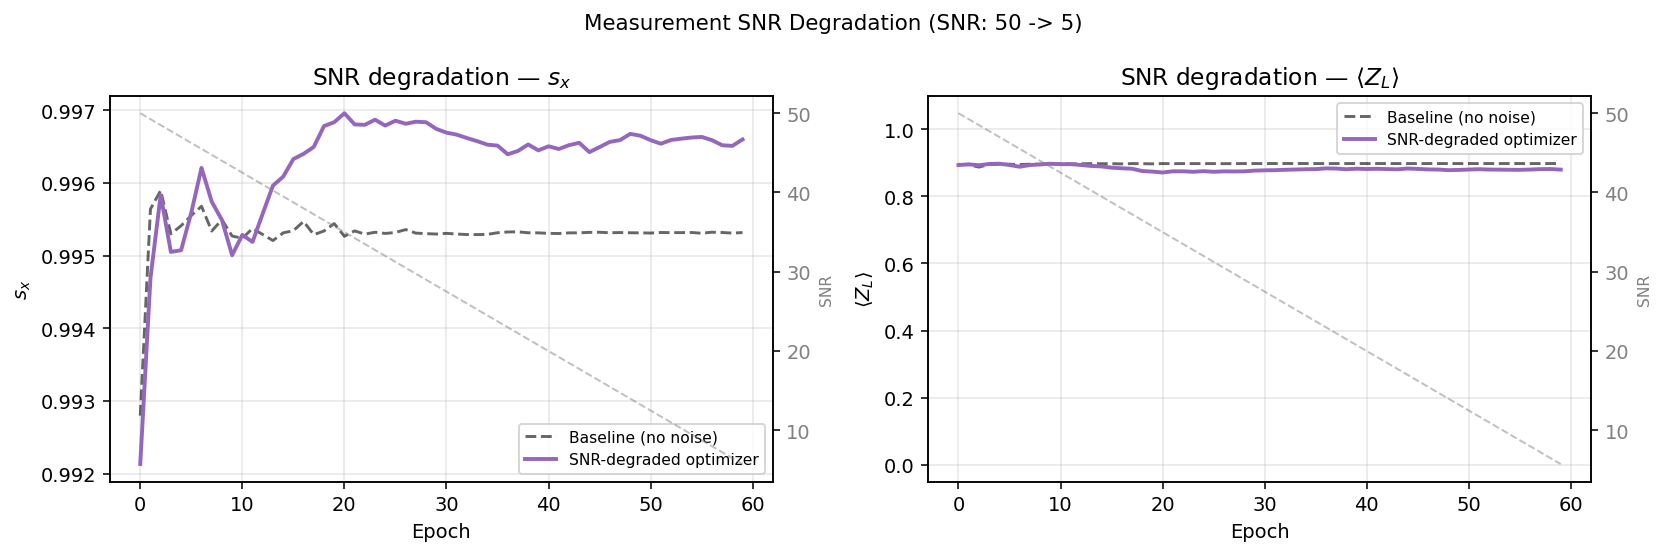

In [11]:
# ── Resilience plots: step-drift benchmark ────────────────────────────────────
#
# Layout: 3 rows (g2 amp, detuning, Kerr) x 2 cols (sx, sz)
# Each panel shows: baseline | drifted | drifted+comp (where available)
# Orange vertical line marks STEP_EPOCH (drift onset).

epochs_arr = jnp.arange(N_EPOCHS)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=140)
fig.suptitle(
    f"Step-Drift Resilience Benchmark  (drift onset at epoch {STEP_EPOCH})",
    fontsize=13, y=1.01
)

panels = [
    # (row title,        sz/sx hist_drifted,   hist_comp or None)
    ("g2 Amplitude Step (+30%)",         hist_amp_step,   None),
    ("Storage Detuning Step (+0.5 MHz)", hist_det_nocomp, hist_det_comp),
    ("Kerr Nonlinearity Step (K=0.15)",  hist_kerr_step,  None),
]

for row, (title, h_drift, h_comp) in enumerate(panels):
    for col, metric in enumerate(['sx', 'sz']):
        ax = axes[row, col]

        if metric == 'sx':
            ylabel = r"$s_x = 1/T_X^{\rm proxy}$"
            subtitle = r"Phase-flip proxy $s_x$  (lower = better)"
        else:
            ylabel = r"$\langle Z_L \rangle$ at $T_Z$"
            subtitle = r"Bit-flip proxy $s_z$  (higher = better)"

        # Baseline
        ax.plot(epochs_arr, hist_baseline[metric],
                'k--', linewidth=1.5, alpha=0.6, label="Baseline (no drift)")

        # Drifted (no knob)
        color = 'tab:red' if metric == 'sx' else 'tab:blue'
        label = "Drifted" if h_comp is None else "Drifted (no knob)"
        ax.plot(epochs_arr, h_drift[metric],
                color=color, linewidth=2, label=label)

        # Drifted + compensation knob
        if h_comp is not None:
            ax.plot(epochs_arr, h_comp[metric],
                    color='tab:green', linewidth=2, linestyle='-.',
                    label=r"Drifted + $\Delta_d$ knob")

        # Drift onset marker
        ax.axvline(STEP_EPOCH, color='darkorange', linestyle=':', linewidth=2,
                   alpha=0.9, label="Drift onset")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}\n{subtitle}", fontsize=9)
        ax.legend(fontsize=7, loc='lower right' if metric == 'sz' else 'upper right')
        ax.grid(True, alpha=0.3)
        if metric == 'sz':
            ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("drift_resilience_step.png", dpi=140, bbox_inches='tight')
plt.show()

# ── Step vs Ramp comparison for g2 amplitude drift ────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
fig2.suptitle("Step vs Ramp Drift Profile — g2 Amplitude", fontsize=11)

for col, metric in enumerate(['sx', 'sz']):
    ax = axes2[col]
    color = 'tab:red' if metric == 'sx' else 'tab:blue'
    ylabel = (r"$s_x$" if metric == 'sx' else r"$\langle Z_L \rangle$")
    ax.plot(epochs_arr, hist_baseline[metric],
            'k--', linewidth=1.5, alpha=0.6, label="Baseline")
    ax.plot(epochs_arr, hist_amp_step[metric],
            color=color, linewidth=2, label="Step drift")
    ax.plot(epochs_arr, hist_amp_ramp[metric],
            color=color, linewidth=2, linestyle=':', label="Ramp drift")
    ax.axvline(STEP_EPOCH, color='darkorange', linestyle=':', linewidth=1.5,
               alpha=0.8, label="Step onset")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"g2 Amplitude: step vs ramp — {ylabel}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metric == 'sz':
        ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("drift_step_vs_ramp.png", dpi=140, bbox_inches='tight')
plt.show()

# ── SNR degradation effect ────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
fig3.suptitle("Measurement SNR Degradation (SNR: 50 -> 5)", fontsize=11)

snr_values = jnp.array([snr_schedule(e) for e in range(N_EPOCHS)])

for col, metric in enumerate(['sx', 'sz']):
    ax = axes3[col]
    color = 'tab:purple'
    ylabel = (r"$s_x$" if metric == 'sx' else r"$\langle Z_L \rangle$")
    ax.plot(epochs_arr, hist_baseline[metric],
            'k--', linewidth=1.5, alpha=0.6, label="Baseline (no noise)")
    ax.plot(epochs_arr, hist_snr[metric],
            color=color, linewidth=2, label="SNR-degraded optimizer")

    ax2 = ax.twinx()
    ax2.plot(epochs_arr, snr_values, color='gray', linewidth=1, linestyle='--', alpha=0.5)
    ax2.set_ylabel("SNR", color='gray', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='gray')

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"SNR degradation — {ylabel}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metric == 'sz':
        ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("drift_snr.png", dpi=140, bbox_inches='tight')
plt.show()

In [12]:
# ── Recovery analysis: quantify optimizer responsiveness ──────────────────────
#
# For each step-drift experiment, we measure:
#   - sz drop: how much the bit-flip proxy falls immediately after drift onset
#   - epochs to 90% recovery: how many epochs after drift onset to regain
#     90% of the baseline's post-step average sz
#   - final sz: where the optimizer settles by the end of the run
#
# This directly characterizes "optimizer responsiveness" in the sense of [2].

def recovery_stats(hist_drift, hist_baseline, metric='sz', threshold=0.90,
                   step_epoch=STEP_EPOCH):
    """
    Returns a dict with:
      drop       - sz decrease at drift onset (baseline_pre - drift_post_immediate)
      epochs_to_recovery - epochs after step_epoch to reach threshold * baseline_post_mean
      final_val  - final value of the metric at the end of the run
    """
    series_drift = jnp.array(hist_drift[metric])
    series_base  = jnp.array(hist_baseline[metric])

    pre_drift_val     = float(series_drift[:step_epoch].mean())
    immediate_post    = float(series_drift[step_epoch])
    drop              = pre_drift_val - immediate_post

    # Reference target: threshold fraction of what the baseline achieves post-step
    base_post_mean = float(series_base[step_epoch:].mean())
    target = threshold * base_post_mean

    epochs_to_rec = None
    for offset, val in enumerate(series_drift[step_epoch:]):
        # For sz: higher is better; for sx: lower is better
        recovered = (float(val) >= target) if metric == 'sz' else (float(val) <= target)
        if recovered:
            epochs_to_rec = offset
            break

    return {
        'drop':               drop,
        'epochs_to_recovery': epochs_to_rec,  # None = did not recover
        'final_val':          float(series_drift[-1]),
        'baseline_final':     float(series_base[-1]),
    }


step_experiments = {
    "g2 Amplitude Step":             hist_amp_step,
    "Detuning Step (no knob)":       hist_det_nocomp,
    "Detuning Step (Delta_d knob)":  hist_det_comp,
    "Kerr Step":                     hist_kerr_step,
}

print(f"Recovery analysis — threshold: 90% of baseline post-step sz\n")
print(f"{'Experiment':<35} {'sz drop':>8} {'Epochs to recover':>18} {'Final sz':>10} {'Baseline sz':>12}")
print("-" * 88)

for exp_name, hist_exp in step_experiments.items():
    # For the comp variant, compare against baseline (same Hamiltonian conditions)
    stats = recovery_stats(hist_exp, hist_baseline, metric='sz')
    drop    = stats['drop']
    rec     = stats['epochs_to_recovery']
    fin     = stats['final_val']
    base_f  = stats['baseline_final']
    rec_str = f"{rec}" if rec is not None else "never"
    print(f"  {exp_name:<33} {drop:>+8.4f} {rec_str:>18} {fin:>10.4f} {base_f:>12.4f}")

print()
print("Notes:")
print("  sz drop > 0: bit-flip protection degrades at drift onset (expected for step drifts)")
print("  'never': optimizer did not recover to 90% of baseline within the run")
print("  Detuning with Delta_d knob should show faster recovery than without")

# ── Summary table: final performance relative to ideal ────────────────────────
print(f"\n{'='*60}")
print("Final sz summary across all experiments")
print(f"{'='*60}")

all_hists = {
    "Baseline":                 hist_baseline,
    "g2 Amplitude Step":        hist_amp_step,
    "g2 Amplitude Ramp":        hist_amp_ramp,
    "Detuning Step (no knob)":  hist_det_nocomp,
    "Detuning Step (+knob)":    hist_det_comp,
    "Kerr Step":                hist_kerr_step,
    "SNR Degradation":          hist_snr,
}

print(f"  {'Experiment':<35} {'Final sz':>9} {'Final sx':>9} {'Final alpha':>12}")
print("  " + "-" * 70)
for name, h in all_hists.items():
    print(f"  {name:<35} {float(h['sz'][-1]):>9.4f} "
          f"{float(h['sx'][-1]):>9.4f} {float(h['alpha'][-1]):>12.4f}")

Recovery analysis — threshold: 90% of baseline post-step sz

Experiment                           sz drop  Epochs to recover   Final sz  Baseline sz
----------------------------------------------------------------------------------------
  g2 Amplitude Step                  +0.0434                  0     0.8978       0.8977
  Detuning Step (no knob)            +0.0807                  0     0.8175       0.8977
  Detuning Step (Delta_d knob)       +0.0817                  0     0.8961       0.8977
  Kerr Step                          +0.0015                  0     0.8970       0.8977

Notes:
  sz drop > 0: bit-flip protection degrades at drift onset (expected for step drifts)
  'never': optimizer did not recover to 90% of baseline within the run
  Detuning with Delta_d knob should show faster recovery than without

Final sz summary across all experiments
  Experiment                           Final sz  Final sx  Final alpha
  -------------------------------------------------------------